# BLS client

navi's `BlsClient` is a thin async wrapper over the Bureau of Labor Statistics
Public Data API: five methods, one per endpoint, each returning a pydantic
model built straight from the wire payload.

This is the walkthrough's arc — surveys, popular series, one series, a plot —
run against the vendor API directly, so the MCP server does **not** need to be
running. The vendor's API key does need to be configured: `BLS_API_KEY` in the
environment. BLS is the one source here that answers without a key at all,
at the lower v1 limits.

What the client does *not* do is the interesting part. The MCP tools hand a
notebook `observations` with an ISO `date` on every row; `BlsClient` hands back
`Results` holding `seriesID` and `periodName`, string values, and no date field
anywhere. The renaming, the parsing and the date derivation are the MCP layer's
work — this notebook is what that layer sits on top of.

In [4]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

from datetime import date
sys.path.append("../../")   # repo root, for `clients`

from matplotlib import pyplot

from lib import config
from lib.utils import print_json_vertical
from lib.env import get_bls_api_key
from clients.bls import BlsClient
from utils import (
    show_client_envelope,
    show_client_surveys,
    show_client_series_catalog,
    show_client_observations,
    client_observation_date,
    client_observation_span,
    client_monthly_observations,
    show_client_suppressed,
    client_observations_to_arrays,
    plot_client_series,
)

pyplot.style.use(config.glyfish_style)

## 1. Discovery

BLS has no search. No endpoint matches text against series, so an id cannot be
looked up by description — discovery runs through the survey programs instead,
and the client's five methods split along exactly that line: three of them find
a series (`get_all_surveys`, `get_survey`, `get_popular_series`) and only two
return observations (`get_series_data`, `get_series_latest`).

Every response carries the same envelope, which is worth printing after each
call. BLS signals failure with HTTP 200 and a `status` other than
`REQUEST_SUCCEEDED`; the client raises `BlsAPIError` on that, so anything that
returns here is a success — advisories and all.

In [5]:
client = BlsClient()
print("BLS_API_KEY configured:", bool(get_bls_api_key(required=False)))

surveys = await client.get_all_surveys()
show_client_envelope(surveys)
print(f"\n{len(surveys.results.survey)} survey programs\n")

matches = show_client_surveys(surveys, match="Current Population")

BLS_API_KEY configured: True
status=REQUEST_SUCCEEDED  response_time=10ms
message: []  -- BLS answered the request as asked

70 survey programs

6 of 70 surveys match 'Current Population'

FM: Marital and family labor force statistics from the Current Population Survey
KV: Veterans Supplement data from the Current Population Survey
LE: Weekly and hourly earnings data from the Current Population Survey
LF: Labor Force Statistics from the Current Population Survey (SIC)
LN: Labor Force Statistics from the Current Population Survey
LU: Union affiliation data from the Current Population Survey


The path from here runs survey → survey metadata → popular series →
catalog. `get_survey` says what one program supports, and its answer is the
first place the wire aliases show through: BLS sends `allowsNetChange`,
`allowsPercentChange` and `hasAnnualAverages`, and the `Survey` model exposes
them under Python names.

`get_popular_series` returns the twenty-five ids people request most, and they
arrive bare — a `BlsSeriesResponse` whose series carry a `series_id` and an
empty `data` list. Fetching them with `catalog=True` is what makes them
readable.

In [6]:
info = await client.get_survey("LN")
print(info.results.survey[0])

popular = await client.get_popular_series("LN")
popular_ids = [series.series_id for series in popular.results.series]
print(f"\n{len(popular_ids)} popular LN series, as returned:")
print(popular_ids)

survey_abbreviation='LN' survey_name='Labor Force Statistics from the Current Population Survey' allows_net_change='true' allows_percent_change='true' has_annual_averages='true'

25 popular LN series, as returned:
['LNS14000000', 'LNS11300000', 'LNS12000000', 'LNS13000000', 'LNS11000000', 'LNS13327709', 'LNU04000000', 'LNS12300000', 'LNS16000000', 'LNU01300000', 'LNU01300002', 'LNU01300001', 'LNS15000000', 'LNS15026639', 'LNS14000006', 'LNS12035019', 'LNS13024887', 'LNU03000000', 'LNU02000000', 'LNS11300060', 'LNS14000009', 'LNU01000000', 'LNS14000003', 'LNS14000012', 'LNS14024887']


In [7]:
last_year = date.today().year - 1

named = await client.get_series_data(
    popular_ids,              # all 25 in one call; the cap is 50
    start_year=last_year,     # one year wide: we are here for the metadata
    end_year=last_year,
    catalog=True,
)

titles = show_client_series_catalog(named)

LNS14000000  (Seas) Unemployment Rate  [Percent or rate]
LNS11300000  (Seas) Labor Force Participation Rate  [Percent or rate]
LNS12000000  (Seas) Employment Level  [Number in thousands]
LNS13000000  (Seas) Unemployment Level  [Number in thousands]
LNS11000000  (Seas) Civilian Labor Force Level  [Number in thousands]
LNS13327709  (Seas) Total unemployed, plus all persons marginally attached to the labor force, plus total employed part time for economic reasons, as a percent of the civilian labor force plus all persons marginally attached to the labor force (U-6)  [Percent or rate]
LNU04000000  (Unadj) Unemployment Rate  [Percent or rate]
LNS12300000  (Seas) Employment-Population Ratio  [Percent or rate]
LNS16000000  Research series, employment adjusted to CES concepts, seasonally adjusted  [Number in thousands]
LNU01300000  (Unadj) Labor Force Participation Rate  [Percent or rate]
LNU01300002  (Unadj) Labor Force Participation Rate - Women  [Percent or rate]
LNU01300001  (Unadj) Labor 

## 2. Retrieving a series

`LNU04000000` is the unemployment rate **unadjusted** — the same measurement as
the headline `LNS14000000` with the seasonal smoothing left off, so the
calendar is still in the numbers.

`get_series_latest` answers "what is the newest figure" in one small call,
which makes it the right place to set the raw payload beside the typed model.
Both requests below ask BLS the same question: `_get` is the client's private
transport and returns the decoded JSON untouched, while `get_series_latest`
runs that same payload through `BlsSeriesResponse`.

In [8]:
series_id = "LNU04000000"

raw = await client._get(f"/timeseries/data/{series_id}", {"latest": "true"})
print("raw payload, exactly as BLS sent it:")
print_json_vertical(raw)

latest = await client.get_series_latest(series_id)
print("\nthe same payload, validated:")
print(latest)

raw payload, exactly as BLS sent it:
{
  "Results": {
    "series": [
      {
        "data": [
          {
            "footnotes": [
              {}
            ],
            "latest": "true",
            "period": "M08",
            "periodName": "August",
            "value": "4.3",
            "year": "2026"
          }
        ],
        "seriesID": "LNU04000000"
      }
    ]
  },
  "message": [],
  "responseTime": 84,
  "status": "REQUEST_SUCCEEDED"
}

the same payload, validated:
status='REQUEST_SUCCEEDED' response_time=96 message=[] results=SeriesResults(series=[Series(series_id='LNU04000000', catalog=None, data=[Observation(year='2026', period='M08', period_name='August', value='4.3', latest='true', footnotes=[Footnote(code=None, text=None)], calculations=None, aspects=[])])])


Read the two side by side and the model's contribution is exactly three
things.

It **validated the shape**. `Results` is an object here, not the array the BLS
documentation describes, and `footnotes` can hold an empty `{}` — both are
pinned down by the models rather than rediscovered at runtime by every caller.

It **renamed the wire aliases**: `Results` → `results`, `responseTime` →
`response_time`, `seriesID` → `series_id`, `periodName` → `period_name`. The
aliases are declared on the model fields, so BLS's own payload validates
unchanged while the attribute names stay readable.

What it did **not** do is convert anything. `value` is still a string, `year`
is still a string, and there is no date field on either side because BLS does
not send one: a row is dated by a year and a period *code*. Deriving a datetime
from that pair is the caller's job here — the MCP layer does it for you, this
notebook does it itself.

In [9]:
observation = latest.results.series[0].data[0]

print(f"alias   Results.series[0].seriesID  ->  {latest.results.series[0].series_id!r}")
print(f"alias   data[0].periodName          ->  {observation.period_name!r}")
print(f"alias   responseTime                ->  {latest.response_time!r}")
print(f"type    value {observation.value!r}  ->  float {float(observation.value)}")
print(f"date    year {observation.year!r} + period {observation.period!r}"
      f"  ->  {client_observation_date(observation).date()}")


alias   Results.series[0].seriesID  ->  'LNU04000000'
alias   data[0].periodName          ->  'August'
alias   responseTime                ->  96
type    value '4.3'  ->  float 4.3
date    year '2026' + period 'M08'  ->  2026-08-01


The other thing the envelope carries is advice, and `message` is
populated on a **successful** response. The case that matters is the twenty-year
cap: BLS does not reject a wider request, it answers it with a shorter series
and mentions the trim only there.

Ask for everything back to 1948 and watch what actually arrives.

In [10]:
everything = await client.get_series_data(
    [series_id],
    start_year=1948,
    end_year=date.today().year,
)
show_client_envelope(everything)

rows = everything.results.series[0].data
print(f"\n{len(rows)} observations, span {client_observation_span(rows)}")
print("\nnewest rows returned:")
show_client_observations(rows, count=3)

status=REQUEST_SUCCEEDED  response_time=106ms
message: Year range has been reduced to the system-allowed limit of 20 years.

240 observations, span ('1948-01-01', '1967-12-01')

newest rows returned:
1967  M12  December   3.5
1967  M11  November   3.7
1967  M10  October    3.8


Note *which* twenty years came back: the oldest ones. The response is a
well-formed run of monthly unemployment rates that happens to stop in the
1960s, and nothing but that one advisory distinguishes it from a complete
answer — a caller who ignores `message` plots the Eisenhower era and labels it
current.

So ask for a window that fits. `annualaverage=True` goes in as well, to show
the other quirk: BLS returns each year's mean as an extra row coded `M13`, and
`M13` names no month, so any date derivation collapses it onto January 1st —
the same date as that year's `M01`. Two rows land on one x value and the period
code is all that separates them.

In [11]:
end_year = date.today().year
start_year = end_year - 19          # 20 years inclusive: exactly the BLS limit

result = await client.get_series_data(
    [series_id],
    start_year=start_year,
    end_year=end_year,
    catalog=True,
    annualaverage=True,
)
show_client_envelope(result)

series = result.results.series[0]
print(f"\n{len(series.data)} observations, span {client_observation_span(series.data)}")
print(f"catalog: {series.catalog.series_title}  [{series.catalog.measure_data_type}]")

collision = [row for row in series.data
             if row.year == str(last_year) and row.period in ("M01", "M13")]
print(f"\nboth rows derive to {last_year}-01-01:")
show_client_observations(collision)

status=REQUEST_SUCCEEDED  response_time=99ms
message: []  -- BLS answered the request as asked

255 observations, span ('2007-01-01', '2026-08-01')
catalog: (Unadj) Unemployment Rate  [Percent or rate]

both rows derive to 2025-01-01:
2025  M13  Annual     4.3
2025  M01  January    4.4


## 3. Plot

Two filters stand between that response and a plot, and both are the caller's
to apply.

The first drops the `M13` rows so each date gets one point. The second is the
withheld values: BLS suppresses a figure by publishing a non-numeric
placeholder such as `-` in place of the number rather than omitting the row, so
`float()` fails on rows that are otherwise well formed. Skipping them silently
would draw a plot with fewer points than the series has observations, so the
count and the dropped rows get printed either way. This window contains one:
October 2025, withheld during the lapse in appropriations and published as `-`
with a footnote saying why.

What makes the picture worth looking at is the saw-tooth riding on top of the
two shocks: unadjusted unemployment peaks every January, bumps again in June as
school leavers enter the labor force, and bottoms out in the autumn. That
yearly ripple is what the seasonally adjusted headline exists to remove, and it
is roughly a percentage point wide — larger than most of the month-to-month
moves the headline number gets reported on.

255 observations, 236 monthly after dropping the M13 annual rows
236 observations, 235 plottable
  withheld: 2025-M10  value='-'  Data unavailable due to the 2025 lapse in appropriations.

plotting 235 points, 2007-01-01 to 2026-08-01, values 3.1 to 14.4


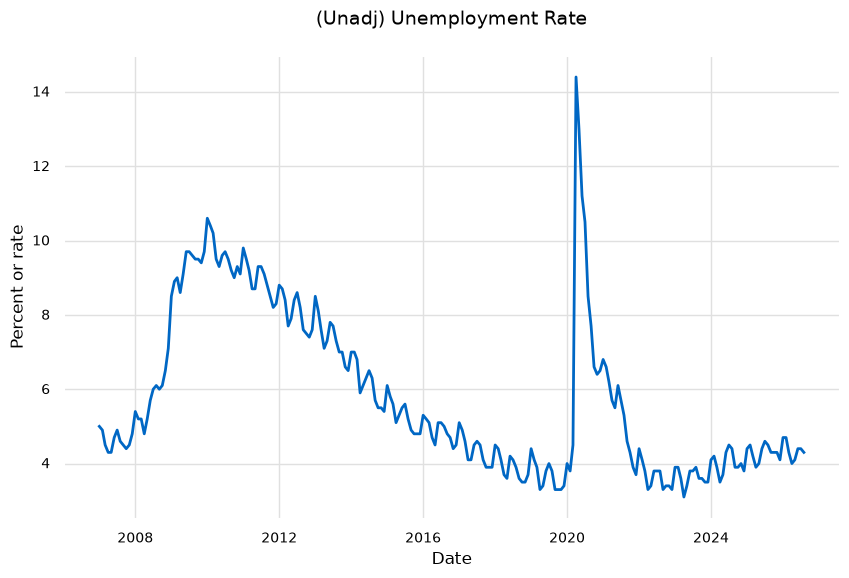

: 

In [ ]:
monthly = client_monthly_observations(series)
print(f"{len(series.data)} observations, {len(monthly)} monthly "
      f"after dropping the M13 annual rows")

withheld = show_client_suppressed(monthly)

values, dates = client_observations_to_arrays(monthly)
print(f"\nplotting {len(values)} points, {dates[0].date()} to {dates[-1].date()}, "
      f"values {values.min()} to {values.max()}")

plot_client_series(series, rows=monthly)

await client.aclose()